<a href="https://colab.research.google.com/github/cicerohen/hands-on-ml-book/blob/main/hands_on_chapter_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Step 1: Setup and Loading Data
First, we need to import our tools and load our dataset of clothing images.

In [1]:
import tensorflow as tf
from tensorflow import keras
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

**Load the Fashion MNIST dataset**


In [2]:
fashion_mnist = keras.datasets.fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### Step 2: Preprocessing the Data
Neural networks prefer to digest small numbers. Because pixel brightness goes from 0 to 255, we divide everything by 255.0 to scale them down to a 0-1 range. We also carve out a small "validation" set to test our model as it learns.

**Scale pixel intensities down to the 0-1 range and create a validation set**


In [3]:
X_valid, X_train = X_train_full[:5000] / 255.0, X_train_full[5000:] / 255.0
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

**Define the human-readable class names for our 10 clothing bins**

In [4]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

### Step 3: Building the Neural Network
Here we build the architecture. We start by flattening the 28x28 pixel image into a single line of data, then pass it through two "hidden layers" of neurons that look for patterns, and finally to an output layer that sorts it into our 10 classes.

**Build a Sequential model**

In [5]:
model = keras.models.Sequential([
    keras.Input(shape=[28, 28]),
    keras.layers.Flatten(),
    keras.layers.Dense(300, activation="relu"),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

**View the architecture summary**

In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

### Step 4: Compiling and Training
Now we give our model its learning rules (loss function and optimizer) and let it practice on the training data for 30 rounds (epochs).

**Compile the model**

In [7]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="sgd",
              metrics=["accuracy"])

**Train the model**

In [8]:
history = model.fit(X_train, y_train, epochs=30, validation_data=(X_valid, y_valid))

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7626 - loss: 0.7234 - val_accuracy: 0.8248 - val_loss: 0.5174
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8314 - loss: 0.4871 - val_accuracy: 0.8532 - val_loss: 0.4368
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8448 - loss: 0.4422 - val_accuracy: 0.8534 - val_loss: 0.4338
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8549 - loss: 0.4143 - val_accuracy: 0.8338 - val_loss: 0.4518
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8615 - loss: 0.3943 - val_accuracy: 0.8596 - val_loss: 0.4050
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8669 - loss: 0.3788 - val_accuracy: 0.8648 - val_loss: 0.3861
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8720 - loss: 0.3662 - val_accuracy: 0.8660 - val_loss: 0.3818
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8751 - loss: 0.3537 - 

**Plot the learning curve to visualize progress**

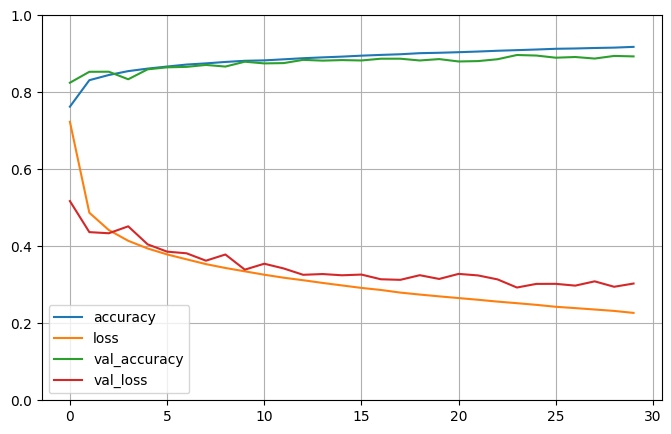

In [9]:
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

### Step 5: Evaluating and Predicting
Finally, we test our trained model on data it has never seen before (X_test) to see how well it actually learned.

**Evaluate accuracy on the test set**

In [10]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8331 - loss: 79.4386


[79.43861389160156, 0.8331000208854675]

**Predict the first 3 items in the test set**

In [11]:
X_new = X_test[:3]
y_pred = np.argmax(model.predict(X_new), axis=-1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step


**Print the predicted names**

In [12]:
print("Predictions:", np.array(class_names)[y_pred])

Predictions: ['Ankle boot' 'Pullover' 'Trouser']
